# Retail Sales Analysis 

To analyze retail sales data and generate actionable business insights 
using SQL for aggregation, Python for analysis, and Power BI for visualization.

In [14]:
# import libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [16]:
warnings.filterwarnings('ignore')

#### Data loading

In [17]:
# read csv file

df= pd.read_csv('Raw_Retail_sales.csv')

In [18]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34.0,BEAUTY,2.944950,46.595094,155.035346
1,2,2023-02-27,CUST002,Female,26.0,Clothing,2.008228,481.384264,1087.085541
2,3,2023-01-13,CUST003,Male,50.0,electronics,0.997843,28.394110,30.542176
3,4,2023-05-21,CUST004,male,37.0,Clothing,1.097376,532.680424,529.051786
4,5,NaN,CUST005,Male,30.0,Beauty,1.962260,45.063955,102.099935
...,...,...,...,...,...,...,...,...,...
1025,713,2023-01-14,CUST713,Male,34.0,Beauty,3.188134,24.394568,81.380131
1026,748,2023-03-20,CUST748,Male,25.0,NaN,2.731723,46.726758,138.904223
1027,644,2023-09-06,CUST644,Male,23.0,Beauty,2.844724,25.736307,79.482034
1028,693,2023-04-23,CUST693,Male,41.0,BEAUTY,3.073197,512.277207,NaN


In [19]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34.0,BEAUTY,2.944950,46.595094,155.035346
1,2,2023-02-27,CUST002,Female,26.0,Clothing,2.008228,481.384264,1087.085541
2,3,2023-01-13,CUST003,Male,50.0,electronics,0.997843,28.394110,30.542176
3,4,2023-05-21,CUST004,male,37.0,Clothing,1.097376,532.680424,529.051786
4,5,NaN,CUST005,Male,30.0,Beauty,1.962260,45.063955,102.099935


#### Data cleaning

Handled missing values, removed duplicates, corrected data types, 
and prepared the dataset for analysis.


In [20]:
df.loc[df['Quantity'] < 1, 'Quantity'] = 1

In [21]:
# how many none values in each column
df.isnull().sum()

Transaction ID       0
Date                 8
Customer ID         21
Gender               0
Age                 22
Product Category    17
Quantity            20
Price per Unit      21
Total Amount        21
dtype: int64

In [22]:
df["Date"]=df["Date"].fillna(df["Date"].ffill())

In [23]:
df = df.dropna(subset=["Customer ID"]).reset_index(drop=True)

In [24]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [25]:
df['Product Category']=df['Product Category'].fillna(df['Product Category'].mode()[0])

In [26]:
df["Quantity"]=df['Quantity'].fillna(df['Quantity'].median())

In [27]:
df['Price per Unit']=df['Price per Unit'].fillna(df['Price per Unit'].mean())

In [28]:
df['Total Amount']=df['Total Amount'].fillna(df['Total Amount'].mean())

In [29]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    1009 non-null   int64  
 1   Date              1009 non-null   object 
 2   Customer ID       1009 non-null   object 
 3   Gender            1009 non-null   object 
 4   Age               1009 non-null   float64
 5   Product Category  1009 non-null   object 
 6   Quantity          1009 non-null   float64
 7   Price per Unit    1009 non-null   float64
 8   Total Amount      1009 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 71.1+ KB


In [31]:
df.shape

(1009, 9)

In [32]:
print(df["Transaction ID"].unique())

[   1    2    3    4    5    6    7    8    9   10   11   12   13   15
   16   17   18   19   20   21   22   23   24   25   26   27   29   30
   31   32   33   34   35   36   37   38   39   40   41   42   43   44
   45   46   47   48   49   50   51   52   53   54   55   56   57   58
   60   61   62   63   64   65   66   67   68   69   70   71   72   73
   74   75   76   77   78   79   80   81   82   83   84   85   86   87
   88   89   90   91   93   94   95   96   97   98   99  100  101  102
  103  104  105  106  107  109  110  111  112  113  114  115  116  117
  118  119  120  121  122  123  124  125  126  127  128  129  130  131
  132  133  134  135  136  137  138  139  140  141  142  143  144  145
  146  147  148  149  150  151  152  153  154  155  156  157  158  159
  160  161  162  163  164  165  166  167  168  169  170  171  172  173
  174  175  176  178  179  180  181  182  183  184  185  186  187  188
  189  190  191  192  193  194  195  196  197  198  199  200  201  202
  203 

In [33]:
print(df["Transaction ID"].value_counts())

Transaction ID
297    2
50     2
474    2
30     2
415    2
      ..
996    1
997    1
998    1
999    1
2      1
Name: count, Length: 980, dtype: int64


In [34]:
df=df.drop_duplicates(subset=['Transaction ID'],keep='first')

In [35]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34.0,BEAUTY,2.944950,46.595094,155.035346
1,2,2023-02-27,CUST002,Female,26.0,Clothing,2.008228,481.384264,1087.085541
2,3,2023-01-13,CUST003,Male,50.0,electronics,1.000000,28.394110,30.542176
3,4,2023-05-21,CUST004,male,37.0,Clothing,1.097376,532.680424,529.051786
4,5,2023-05-21,CUST005,Male,30.0,Beauty,1.962260,45.063955,102.099935
...,...,...,...,...,...,...,...,...,...
975,996,2023-05-16,CUST996,Male,62.0,Clothing,1.000000,53.883651,46.529417
976,997,2023-11-17,CUST997,Male,52.0,Beauty,2.766933,193.992362,83.972312
977,998,2023-10-29,CUST998,Female,23.0,beauty,3.834713,27.429202,91.922891
978,999,2023-12-05,CUST999,female,36.0,Electronics,2.950571,45.633148,148.048886


In [36]:
print(df["Customer ID"].unique())

['CUST001' 'CUST002' 'CUST003' 'CUST004' 'CUST005' 'CUST006' 'CUST007'
 'CUST008' 'CUST009' 'CUST010' 'CUST011' 'CUST012' 'CUST013' 'CUST015'
 'CUST016' 'CUST017' 'CUST018' 'CUST019' 'CUST020' 'CUST021' 'CUST022'
 'CUST023' 'CUST024' 'CUST025' 'CUST026' 'CUST027' 'CUST029' 'CUST030'
 'CUST031' 'CUST032' 'CUST033' 'CUST034' 'CUST035' 'CUST036' 'CUST037'
 'CUST038' 'CUST039' 'CUST040' 'CUST041' 'CUST042' 'CUST043' 'CUST044'
 'CUST045' 'CUST046' 'CUST047' 'CUST048' 'CUST049' 'CUST050' 'CUST051'
 'CUST052' 'CUST053' 'CUST054' 'CUST055' 'CUST056' 'CUST057' 'CUST058'
 'CUST060' 'CUST061' 'CUST062' 'CUST063' 'CUST064' 'CUST065' 'CUST066'
 'CUST067' 'CUST068' 'CUST069' 'CUST070' 'CUST071' 'CUST072' 'CUST073'
 'CUST074' 'CUST075' 'CUST076' 'CUST077' 'CUST078' 'CUST079' 'CUST080'
 'CUST081' 'CUST082' 'CUST083' 'CUST084' 'CUST085' 'CUST086' 'CUST087'
 'CUST088' 'CUST089' 'CUST090' 'CUST091' 'CUST093' 'CUST094' 'CUST095'
 'CUST096' 'CUST097' 'CUST098' 'CUST099' 'CUST100' 'CUST101' 'CUST102'
 'CUST

In [37]:
df["Customer ID"].value_counts()

Customer ID
CUST1000    1
CUST001     1
CUST002     1
CUST003     1
CUST983     1
           ..
CUST009     1
CUST008     1
CUST007     1
CUST006     1
CUST005     1
Name: count, Length: 980, dtype: int64

In [38]:
df["Gender"].unique()

array(['Male ', 'Female', 'Male', 'male', 'FEMALE', 'Female ', 'female',
       'MALE'], dtype=object)

In [39]:
# correcting  Inconsistent Format

In [40]:
df['Gender'] = df['Gender'].str.lower().str.capitalize().str.strip()

In [41]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [42]:
df["Product Category"].unique()

array(['BEAUTY', 'Clothing ', 'electronics', 'Clothing', 'Beauty',
       'Beauty ', 'Electronics', 'Electronics ', 'clothing', 'CLOTHING',
       'ELECTRONICS', 'beauty'], dtype=object)

In [43]:
df['Product Category'] = df['Product Category'].str.lower().str.capitalize().str.strip()

In [44]:
df["Product Category"].unique()

array(['Beauty', 'Clothing', 'Electronics'], dtype=object)

In [45]:
# findind outliers

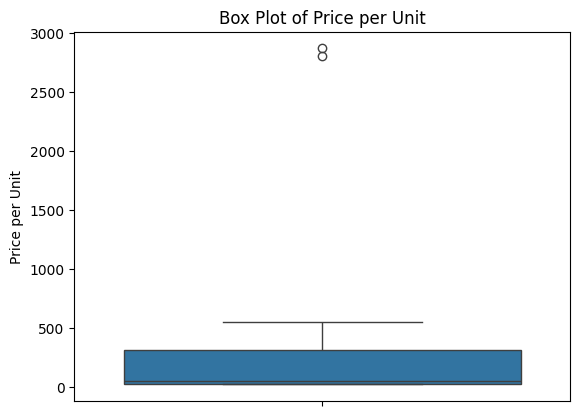

In [46]:
sns.boxplot(df['Price per Unit'])  
plt.title('Box Plot of Price per Unit')
plt.show()

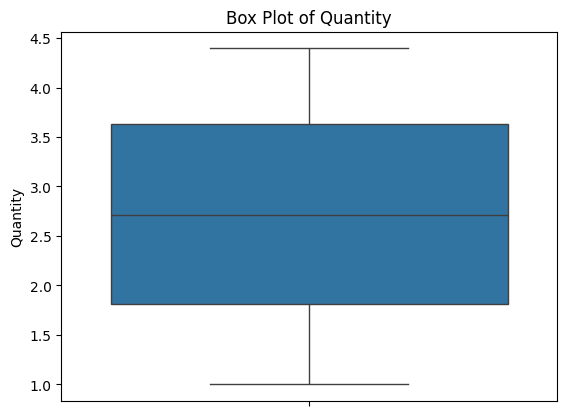

In [47]:
sns.boxplot(df['Quantity'])  
plt.title('Box Plot of Quantity')
plt.show()

In [48]:
# handling outliers

In [49]:


Q1 = df['Price per Unit'].quantile(0.25)
Q3 = df['Price per Unit'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Price per Unit'] >= lower_bound) & (df['Price per Unit'] <= upper_bound)]

In [50]:
df.dtypes

Transaction ID        int64
Date                 object
Customer ID          object
Gender               object
Age                 float64
Product Category     object
Quantity            float64
Price per Unit      float64
Total Amount        float64
dtype: object

In [51]:
df['Transaction ID'] = df['Transaction ID'].astype(str)

In [52]:
df['Transaction ID'] = 'TXN' + df['Transaction ID'].astype(str)

In [53]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [54]:
df = df.dropna(subset=['Age']).reset_index(drop=True)
df['Age'] = df['Age'].astype(int)

In [55]:
df = df.dropna(subset=['Quantity']).reset_index(drop=True)
df['Quantity'] = df['Quantity'].astype(int)

In [56]:
df['Price per Unit'] = df['Price per Unit'].round(2)

In [57]:
df['Total Amount'] = df['Total Amount'].round(2)

In [58]:
df.dtypes

Transaction ID              object
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit             float64
Total Amount               float64
dtype: object

In [59]:
df=df.drop('Total Amount',axis=1)

In [60]:
df['Total Amount']=(df['Quantity']*df['Price per Unit'])

In [61]:
df.reset_index(drop=True, inplace=True)

In [62]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,TXN1,2023-11-24,CUST001,Male,34,Beauty,2,46.60,93.20
1,TXN2,2023-02-27,CUST002,Female,26,Clothing,2,481.38,962.76
2,TXN3,2023-01-13,CUST003,Male,50,Electronics,1,28.39,28.39
3,TXN4,2023-05-21,CUST004,Male,37,Clothing,1,532.68,532.68
4,TXN5,2023-05-21,CUST005,Male,30,Beauty,1,45.06,45.06
...,...,...,...,...,...,...,...,...,...
973,TXN996,2023-05-16,CUST996,Male,62,Clothing,1,53.88,53.88
974,TXN997,2023-11-17,CUST997,Male,52,Beauty,2,193.99,387.98
975,TXN998,2023-10-29,CUST998,Female,23,Beauty,3,27.43,82.29
976,TXN999,2023-12-05,CUST999,Female,36,Electronics,2,45.63,91.26


In [63]:
df.to_csv('Retail.Sales.csv', index=False)

In [64]:
pip install pandas mysql-connector-python


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: C:\Users\Hamada Salim G-Trd\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


#### SQL-Based Aggregation

Used SQL queries to perform data aggregation such as total sales by category, 
monthly revenue trends, and product-wise performance analysis.


In [65]:
import mysql.connector
import pandas as pd

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="YOUR_USERNAME",
    password="YOUR_PASSWORD",
    database="YOUR_DATABASE"
)
cursor = conn.cursor()


#Create Table 
create_table_query = """
CREATE TABLE IF NOT EXISTS RetailSaless (
    Transaction_ID VARCHAR(50) PRIMARY KEY,
    Date DATE,
    Customer_ID VARCHAR(50),
    Gender ENUM('Male', 'Female'),
    Age INT,
    Product_Category VARCHAR(100),
    Quantity INT,
    Price_Per_Unit DECIMAL(10,2),
    Total_Amount DECIMAL(10,2)
);
"""

# Execute the query
cursor.execute(create_table_query)
print("Table 'RetailSaless' created successfully!")


# Load file
df = pd.read_csv("D:/noora/DATA ANALYTICS/Beat/PROJECT/Retail.Sales.csv")  PROJECT/Retail.Sales.csv

# Insert data
for _, row in df.iterrows():
    sql = """INSERT INTO RetailSaless 
             (Transaction_ID, Date, Customer_ID, Gender, Age, Product_Category, Quantity, Price_Per_Unit, Total_Amount)
             VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s)"""
    values = tuple(row)
    cursor.execute(sql, values)

conn.commit()
print("Data inserted successfully!")


# Check row count
cursor.execute("SELECT COUNT(*) FROM RetailSaless;")
row_count = cursor.fetchone()[0]
print(f"Total Rows in RetailSales: {row_count}")

# Fetch first 5 rows
cursor.execute("SELECT * FROM RetailSaless LIMIT 5;")
rows = cursor.fetchall()

# Print data
print("First 5 Rows:")
for row in rows:
    print(row)
    


ProgrammingError: 1045 (28000): Access denied for user 'YOUR_USERNAME'@'localhost' (using password: YES)

In [ ]:

# total sales amount

cursor.execute("SELECT SUM(Total_Amount) FROM RetailSaless;")
total_sales = cursor.fetchone()[0]
print(f"Total Sales Amount: {total_sales}")



In [ ]:

# which category generate the most revenue

cursor.execute("""
    SELECT Product_Category, SUM(Total_Amount) AS Total_Sales
    FROM RetailSales
    GROUP BY Product_Category
    ORDER BY Total_Sales DESC;
""")
category_sales = cursor.fetchall()

print("Total Sales by Product Category:")
for row in category_sales:
    print(row)

In [ ]:
profi

In [ ]:
# Example bar plot
sns.barplot(data=category_sales, x="Product_Category", y="Revenue")
plt.xticks(rotation=45)
plt.title("Revenue by Product Category")
plt.show()


In [ ]:

# top 5 customer

cursor.execute("""
    SELECT Customer_ID, SUM(Total_Amount) AS Total_Spent
    FROM RetailSales
    GROUP BY Customer_ID
    ORDER BY Total_Spent DESC
    LIMIT 5;
""")
top_customers = cursor.fetchall()

print("Top 5 Customers by Spending:")
for row in top_customers:
    print(row)

In [ ]:

# sales perform over time

cursor.execute("""
    SELECT DATE_FORMAT(Date, '%Y-%m') AS Month, SUM(Total_Amount) AS Total_Sales
    FROM RetailSales
    GROUP BY Month
    ORDER BY Month;
""")
monthly_sales = cursor.fetchall()

print("Monthly Sales Trend:")
for row in monthly_sales:
    print(row)

In [ ]:

# spending patterns male and female

cursor.execute("""
    SELECT Gender, SUM(Total_Amount) AS Total_Sales
    FROM RetailSales
    GROUP BY Gender;
""")
gender_sales = cursor.fetchall()

print("Sales by Gender:")
for row in gender_sales:
    print(row)

In [ ]:

# high demand product

cursor.execute("""
    SELECT Product_Category, SUM(Quantity) AS Total_Quantity_Sold
    FROM RetailSales
    GROUP BY Product_Category
    ORDER BY Total_Quantity_Sold DESC
    LIMIT 5;
""")
top_products = cursor.fetchall()

print("Top-Selling Products:")
for row in top_products:
    print(row)

In [ ]:
cursor.execute("""
    SELECT 
        DATE_FORMAT(Date, '%Y-%m') AS Month,
        SUM(Total_Amount) AS Monthly_Sales
    FROM RetailSales
    GROUP BY Month
    ORDER BY Month;
""")

monthly_sales = cursor.fetchall()

print("Monthly Sales Trend:")
for row in monthly_sales:
    print(row)


In [ ]:
cursor.execute("""
    SELECT Date, SUM(Total_Amount) AS Daily_Sales
    FROM RetailSales
    GROUP BY Date
    ORDER BY Date;
""")
daily_sales = cursor.fetchall()

print("Daily Sales Trend:")
for row in daily_sales:
    print(row)

In [ ]:

# AVERAGE SPEND BY AGE GROUP

cursor.execute("""
    SELECT 
        CASE 
            WHEN Age BETWEEN 18 AND 25 THEN '18-25'
            WHEN Age BETWEEN 26 AND 35 THEN '26-35'
            WHEN Age BETWEEN 36 AND 45 THEN '36-45'
            WHEN Age BETWEEN 46 AND 60 THEN '46-60'
            ELSE '60+'
        END AS Age_Group,
        AVG(Total_Amount) AS Avg_Spending
    FROM RetailSales
    GROUP BY Age_Group
    ORDER BY Age_Group;
""")
age_spending = cursor.fetchall()

print("Average Spending Per Age Group:")
for row in age_spending:
    print(row)

In [ ]:
# customers who bought more than 3 quantity

cursor.execute("""
    SELECT Customer_ID, COUNT(Transaction_ID) AS Order_Count
    FROM RetailSales
    WHERE Quantity > 3
    GROUP BY Customer_ID
    ORDER BY Order_Count DESC;
""")
big_orders = cursor.fetchall()

print("Customers Who Bought More Than 5 Items in a Single Purchase:")
for row in big_orders:
    print(row)


In [ ]:

# most revenue generated product

cursor.execute("""
    SELECT Product_Category, SUM(Total_Amount) AS Total_Revenue
    FROM RetailSales
    GROUP BY Product_Category
    ORDER BY Total_Revenue DESC;
""")
high_revenue_products = cursor.fetchall()

print("Products That Generated the Most Revenue:")
for row in high_revenue_products:
    print(row)

#### Key Business Insights

- Identified highest revenue-generating product categories.
- Observed seasonal sales trends across months.
- Determined top-performing regions.
- Highlighted areas where sales decline occurred.


#### Power BI Dashboard

After cleaning and analyzing the dataset using Python,
the processed data was exported to Power BI to build
interactive dashboards including:

- Monthly Sales Trends
- Category-wise Performance
- KPI Cards
- Interactive Filters
